![a workflow to be used to persistence implementation](images/persistence.png)

In [48]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [49]:
load_dotenv()
llm = ChatOpenAI()

In [37]:
class JokeState(TypedDict):
    topic : str
    joke : str
    explanation : str
    

In [38]:
def gen_joke(state:JokeState):

    topic = state['topic']

    prompt = f"Generate a joke about this topic : {topic}"

    response = llm.invoke(prompt)

    return {'joke': response.content}

def gen_explanation(state: JokeState):

    topic = state['topic']
    joke = state['joke']

    prompt = f' Previously you created this joke : {joke}, about this topic:{topic}. Now you need to explain the joke.'

    responose = llm.invoke(prompt)

    return {'explanation': responose.content}

In [39]:
graph = StateGraph(JokeState)

graph.add_node("generate joke", gen_joke)
graph.add_node('generate explanation', gen_explanation)

graph.add_edge(START, 'generate joke')
graph.add_edge('generate joke', 'generate explanation')
graph.add_edge('generate explanation', END)

checkpointer = InMemorySaver()

jokegenerater = graph.compile(checkpointer=checkpointer)

In [40]:
initial_state = {'topic': 'pizza'}
config = {'configurable':{'thread_id':'1'}}

response = jokegenerater.invoke(initial_state,config=config)



In [41]:
response

{'topic': 'pizza',
 'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!",
 'explanation': 'The joke plays on the idea of a pizza needing to see a therapist because it can\'t hold itself together due to too many toppings. This is a play on words, as "holding it all together" can refer to both the physical structure of the pizza (if it has too many toppings, it may fall apart) and a person\'s mental or emotional state (if someone is overwhelmed or struggling, they may say they "can\'t hold it all together"). In this case, the pizza is humorously personified as needing therapy for its inability to maintain its shape due to excessive toppings.'}

In [42]:
jokegenerater.get_state(config=config)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!", 'explanation': 'The joke plays on the idea of a pizza needing to see a therapist because it can\'t hold itself together due to too many toppings. This is a play on words, as "holding it all together" can refer to both the physical structure of the pizza (if it has too many toppings, it may fall apart) and a person\'s mental or emotional state (if someone is overwhelmed or struggling, they may say they "can\'t hold it all together"). In this case, the pizza is humorously personified as needing therapy for its inability to maintain its shape due to excessive toppings.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19319a-70ca-6b8a-8002-b9575b186f4b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-08T11:09:41.128692+00:00', parent_config={'configurable': {

In [43]:
# intermediate state values

list(jokegenerater.get_state_history(config=config))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!", 'explanation': 'The joke plays on the idea of a pizza needing to see a therapist because it can\'t hold itself together due to too many toppings. This is a play on words, as "holding it all together" can refer to both the physical structure of the pizza (if it has too many toppings, it may fall apart) and a person\'s mental or emotional state (if someone is overwhelmed or struggling, they may say they "can\'t hold it all together"). In this case, the pizza is humorously personified as needing therapy for its inability to maintain its shape due to excessive toppings.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19319a-70ca-6b8a-8002-b9575b186f4b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-08T11:09:41.128692+00:00', parent_config={'configurable': 

In [44]:
config2 = {'configurable':{'thread_id': '2'}}
initial_state2 = {'topic': 'pasta'}

response1 = jokegenerater.invoke(initial_state2, config=config2)

In [45]:
response1

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to the party? Because it heard it was going to be a pasta-tively good time!',
 'explanation': 'The joke plays on the pun of "pasta-tively" sounding like "positively." The spaghetti went to the party because it heard it was going to be a great time for pasta lovers, which further emphasizes the play on words. By combining the idea of a fun party with the love of pasta, the joke creates a lighthearted and humorous atmosphere.'}

In [46]:
list(jokegenerater.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to the party? Because it heard it was going to be a pasta-tively good time!', 'explanation': 'The joke plays on the pun of "pasta-tively" sounding like "positively." The spaghetti went to the party because it heard it was going to be a great time for pasta lovers, which further emphasizes the play on words. By combining the idea of a fun party with the love of pasta, the joke creates a lighthearted and humorous atmosphere.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f19319a-f290-677d-8002-952ed862e462'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-08T11:09:54.736319+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f19319a-dae2-69a3-8001-3be032b94f81'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to the party? Because it heard

# Benefits pf persistence - 
- short time memory introduction in the workflow
- HITL can be introduced
- Fault tolerrance
- TIme travel

## 1. Time travel
 
Already we have generated jokes on Pizza and Pasta. 
Now I want to go the stage where the topic was given. And from that checkpoint I want to generate eveything.


- for that first find get_state_history, and the need to go the value topic, and find the "checkpint_id", with this id I can reach to checkpoint id. 


In [51]:
jokegenerater.get_state({"configurable":{'thread_id':"1", "checkpoint_id": '1f19319a-36fa-6dde-8000-e7ab69d2a276'}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f19319a-36fa-6dde-8000-e7ab69d2a276'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-08T11:09:35.066671+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19319a-36f8-66cc-bfff-331529f8fe8c'}}, tasks=(PregelTask(id='0da83a75-b428-25f4-ed48-a99f3874b1b6', name='generate joke', path=('__pregel_pull', 'generate joke'), error=None, interrupts=(), state=None, result={'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!"}),), interrupts=())

### 1.1 invoking again to run the workflow with same iput used before.

In [53]:
#now from this checkpoint I will run this experiment
regenerate = jokegenerater.invoke(None, {"configurable":{'thread_id':"1", "checkpoint_id": '1f19319a-36fa-6dde-8000-e7ab69d2a276'}})
regenerate


{'topic': 'pizza',
 'joke': 'Why did the pizza go to school?\n\nBecause it wanted to be a little slice-educated!',
 'explanation': 'The joke plays on the similarity in sound between "slice" and "sly," making it seem like the pizza wanted to be "sly-educated" instead of "slice-educated." It\'s a play on words that adds a humorous twist to the idea of a pizza attending school.'}

In [54]:
list(jokegenerater.get_state_history(config=config))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to school?\n\nBecause it wanted to be a little slice-educated!', 'explanation': 'The joke plays on the similarity in sound between "slice" and "sly," making it seem like the pizza wanted to be "sly-educated" instead of "slice-educated." It\'s a play on words that adds a humorous twist to the idea of a pizza attending school.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1931c7-88ce-6cd9-8002-048305a3049e'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-08T11:29:51.606498+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1931c7-75dd-6142-8001-39fdc508d072'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to school?\n\nBecause it wanted to be a little slice-educated!'}, next=('generate explanation',), config={'configurable': {'thread_id': '1

![This is what happened above](images/timetravel1.png)

### 1.2. Updating state:
we can go back to the previous state and update the state value and we can rerun the workflow again

![updating state value](images/timetravel2.png)

In [57]:
jokegenerater.update_state({'configurable':{"thread_id":1, "checkpoint_id":'1f19319a-36fa-6dde-8000-e7ab69d2a276', "checkpoint_ns":""}}, {'topic':"somosa"})
list(jokegenerater.get_state_history(config=config))

[StateSnapshot(values={'topic': 'somosa'}, next=('generate joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1931dc-72e1-6e6a-8001-27add80e6c59'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-08T11:39:13.021911+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19319a-36fa-6dde-8000-e7ab69d2a276'}}, tasks=(PregelTask(id='5d80ba0e-2d30-8dc1-397f-da762fe8b115', name='generate joke', path=('__pregel_pull', 'generate joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'somosa'}, next=('generate joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1931db-62d4-6bcf-8001-c8a5c1cd8a9f'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-08T11:38:44.495252+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id

In [60]:
# now I will go to the somosa node and generate jokes on somosa. 

jokegenerater.invoke(None, config={"configurable":{'thread_id':'1', "checkpoint_id":'1f1931dc-72e1-6e6a-8001-27add80e6c59'}})

{'topic': 'somosa',
 'joke': 'Why was the samosa always invited to parties? Because it was always the life of the samosa!',
 'explanation': 'The joke plays on the double meaning of "life of the party," which typically refers to someone who is lively, fun, and entertaining at social gatherings. In this case, the joke replaces "party" with "samosa," implying that the samosa is so enjoyable and popular that it is always invited to events and gatherings. This funny twist on the phrase adds humor to the joke and makes it enjoyable to those who understand the play on words.'}

In [61]:
list(jokegenerater.get_state_history(config=config))

[StateSnapshot(values={'topic': 'somosa', 'joke': 'Why was the samosa always invited to parties? Because it was always the life of the samosa!', 'explanation': 'The joke plays on the double meaning of "life of the party," which typically refers to someone who is lively, fun, and entertaining at social gatherings. In this case, the joke replaces "party" with "samosa," implying that the samosa is so enjoyable and popular that it is always invited to events and gatherings. This funny twist on the phrase adds humor to the joke and makes it enjoyable to those who understand the play on words.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1931f4-43ee-606c-8003-e96bed4f1409'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-08T11:49:52.343665+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1931f4-2774-692d-8002-3640d01f8c8d'}}, tasks=(), interrupts=()),
 StateSnapsh

## 2 . Fault Tolerance

![fault simulation](images/interrupt.png)


We are going to simulate fault and code down there. 

In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [17]:
# state define
class CrashState(TypedDict):

    input : str
    step1 : str
    step2 : str
    step3 : str

In [22]:
def step_1(state: CrashState):
    print("step 1 executed")

    return {'step1': "done", "input": state[ 'input']}

def step_2(state: CrashState):

    time.sleep(10)
    print("step 2 executed")

    return {'step2': "done"}

def step_3(state: CrashState):
    print("step 3 executed")

    return {'step3': "done"}

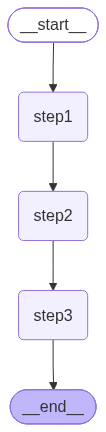

In [23]:
graph = StateGraph(CrashState)

graph.add_node('step1', step_1)
graph.add_node('step2', step_2)
graph.add_node('step3', step_3)

graph.add_edge(START, "step1")
graph.add_edge("step1", "step2")
graph.add_edge("step2", "step3")
graph.add_edge("step3", END)


checkpointer = InMemorySaver() 
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [24]:
# we will interrupt the execution before step 2 happens. Then we will resume that workflow with previous state values. 
try:

    print("Running graph: Please manually interrupt during step 2...")
    config3 = {"configurable":{"thread_id":'1'}}
    initial_state = {'input':"start"}
    workflow.invoke(initial_state, config=config3 )
except KeyboardInterrupt:
    print("Kernel manullay interrupted. Crash simulation")

Running graph: Please manually interrupt during step 2...
step 1 executed
Kernel manullay interrupted. Crash simulation


In [26]:
workflow.get_state(config=config3)

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193173-5967-6056-8001-2ff706771a31'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-08T10:52:11.777851+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193173-5964-6943-8000-2068c0a6da28'}}, tasks=(PregelTask(id='b5b52d52-41b4-b275-cdfa-37d0db8b53df', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [28]:
list(workflow.get_state_history(config=config3))


[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193173-5967-6056-8001-2ff706771a31'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-08T10:52:11.777851+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193173-5964-6943-8000-2068c0a6da28'}}, tasks=(PregelTask(id='b5b52d52-41b4-b275-cdfa-37d0db8b53df', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193173-5964-6943-8000-2068c0a6da28'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-08T10:52:11.776851+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193173-595f-616

In [29]:
# resuming the workflow again, without providing any input or initial state. 

final_state = workflow.invoke(None, config=config3)
print("Final state",final_state)

step 2 executed
step 3 executed
Final state {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [31]:
list(workflow.get_state_history(config=config3))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193181-f86d-644d-8003-eaa1c1b47ab7'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-08T10:58:44.262407+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193181-f86a-6ef0-8002-a113d3289c85'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193181-f86a-6ef0-8002-a113d3289c85'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-08T10:58:44.261451+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193173-5967-6056-8001-2ff706771a31'}}, tasks=(PregelTask(id='2c7598f4-82f2-7fcd-32cf-55beeda3e200', name='st